<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/scripts/monty_hall_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import numpy as np

def run_monty_hall_simulation_N_doors(num_trials, N_doors):
    """
    N개의 문에 대한 몬티 홀 문제를 시뮬레이션하여 승률을 계산합니다.
    몬티는 참가자의 선택 및 자동차 문을 제외한 모든 염소 문(N-2개)을 열어줍니다.

    :param num_trials: 시뮬레이션을 수행할 횟수
    :param N_doors: 문의 총 개수 (예: 1000)
    :return: (선택 고수 승률, 선택 변경 승률)
    """
    if N_doors < 3:
        raise ValueError("문의 개수는 최소 3개 이상이어야 합니다.")

    switch_wins = 0
    stay_wins = 0
    # 문 리스트 생성 (0부터 N-1까지)
    doors = list(np.arange(N_doors))

    for _ in range(num_trials):
        # 1. 자동차(상금) 위치 설정 및 참가자의 첫 선택
        car_door = random.choice(doors)
        first_choice = random.choice(doors)

        # 2. 몬티의 개입
        # 몬티는 참가자의 선택 및 자동차 문을 제외한 모든 염소 문(N-2개)을 열어줍니다.
        # 따라서 닫혀있는 문은 first_choice와 car_door, 단 2개만 남게 됩니다.

        # Determine the doors Monty can open (goat doors, not car, not first choice)
        monty_openable_doors = [d for d in doors if d != car_door and d != first_choice]

        # Monty opens N_doors - 2 goat doors
        # In the N-door problem with Monty opening N-2 doors, there are only two closed doors left:
        # the player's initial choice and the remaining door that Monty did not open.
        # This remaining door is the car door.


        # --- 결과 기록 ---

        # A. 선택 고수 (Stay) 전략
        if first_choice == car_door:
            stay_wins += 1

        # B. 선택 변경 (Switch) 전략
        # When switching, the player wins if the initial choice was a goat door.
        # When the initial choice is a goat door, the car is behind one of the other N-1 doors.
        # Monty opens N-2 goat doors, which means he opens all goat doors except the initial choice.
        # The only two closed doors are the initial choice (goat) and the car door.
        # So, switching always leads to the car in this case.
        # When the initial choice is the car door, Monty can open any N-2 of the N-1 goat doors.
        # The two closed doors are the initial choice (car) and one of the goat doors Monty did not open.
        # Switching leads to a loss.

        if first_choice != car_door:
             # If initial choice is a goat, switching always wins in this N-door variation
             switch_wins += 1
        else:
             # If initial choice is the car, switching always loses in this N-door variation
             pass # No win added for switching

    stay_probability = stay_wins / num_trials
    switch_probability = switch_wins / num_trials

    return stay_probability, switch_probability

# 시뮬레이션 설정
N_DOORS = 100   # 문의 개수 설정 (1000개)
NUM_TRIALS = 20000  # 시뮬레이션 반복 횟수 (정확도를 위해 높게 설정)

# 시뮬레이션 실행
stay_prob, switch_prob = run_monty_hall_simulation_N_doors(NUM_TRIALS, N_DOORS)

# 이론값 계산
stay_theory = 1 / N_DOORS
switch_theory = (N_DOORS - 1) / N_DOORS

print(f"--- 몬티 홀 시뮬레이션 결과 (문 {N_DOORS}개, 총 {NUM_TRIALS}회) ---")
print(f"선택 고수 (Stay) 승률: {stay_prob:.4f} (이론값: {stay_theory:.4f})")
print(f"선택 변경 (Switch) 승률: {switch_prob:.4f} (이론값: {switch_theory:.4f})")
print("\n" + "="*50)
print("🔑 확률적 시사점:")
print(f"문 {N_DOORS}개일 때, 선택 변경이 고수보다 약 {round(switch_theory/stay_theory)}배 더 유리합니다.")
print(f"선택을 바꿀 때, 승률이 {switch_theory*100:.1f}%로 압도적으로 높습니다.")

--- 몬티 홀 시뮬레이션 결과 (문 100개, 총 20000회) ---
선택 고수 (Stay) 승률: 0.0095 (이론값: 0.0100)
선택 변경 (Switch) 승률: 0.9905 (이론값: 0.9900)

🔑 확률적 시사점:
문 100개일 때, 선택 변경이 고수보다 약 99배 더 유리합니다.
선택을 바꿀 때, 승률이 99.0%로 압도적으로 높습니다.


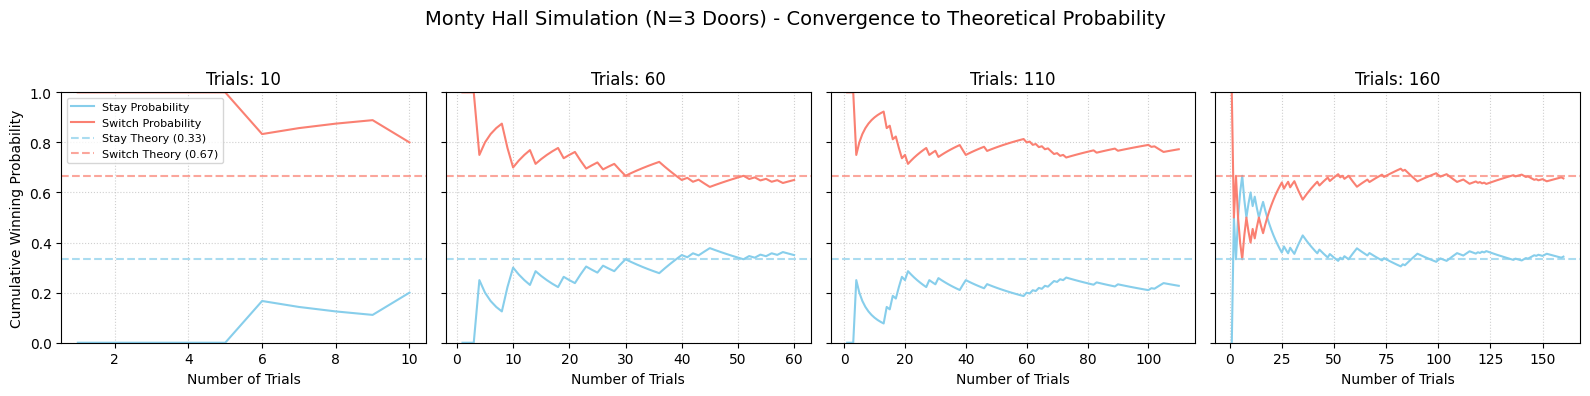

이 시각화는 대수의 법칙(Law of Large Numbers)을 보여줍니다.
시뮬레이션 횟수(Trials)가 증가할수록, 승률은 이론값(Stay: 0.33, Switch: 0.67)에 수렴합니다.


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

def run_monty_hall_single_trial(N_doors=3):
    """단일 몬티 홀 게임을 실행하고, 고수 및 변경 전략의 승패를 반환합니다."""
    doors = list(range(N_doors))
    car_door = random.choice(doors)
    first_choice = random.choice(doors)

    # 몬티가 열어줄 문은 first_choice와 car_door가 아닌 문 중 하나입니다.
    monty_options = [d for d in doors if d != car_door and d != first_choice]

    # 몬티가 반드시 염소 문을 열어줍니다. (N=3이므로 하나만 엽니다)
    monty_open = random.choice(monty_options)

    # A. 선택 고수 (Stay) 전략 결과 (1=승리, 0=패배)
    stay_win = 1 if first_choice == car_door else 0

    # B. 선택 변경 (Switch) 전략 결과
    # 닫혀있는 문 중 first_choice가 아닌 문을 선택
    closed_doors = [d for d in doors if d != monty_open]
    switched_choice = [d for d in closed_doors if d != first_choice][0]
    switch_win = 1 if switched_choice == car_door else 0

    return stay_win, switch_win

def simulate_monty_hall_progress(num_trials, N_doors=3):
    """누적 횟수에 따른 승률 변화를 계산합니다."""
    stay_results = []
    switch_results = []

    for i in range(1, num_trials + 1):
        stay_win, switch_win = run_monty_hall_single_trial(N_doors)

        # 누적 승리 횟수 업데이트
        stay_results.append(stay_win)
        switch_results.append(switch_win)

    # 누적 승률 계산
    stay_cumulative_prob = np.cumsum(stay_results) / np.arange(1, num_trials + 1)
    switch_cumulative_prob = np.cumsum(switch_results) / np.arange(1, num_trials + 1)

    return stay_cumulative_prob, switch_cumulative_prob

# 시뮬레이션 설정
N_DOORS = 3
TRIAL_COUNTS = np.arange(10, 201, 50)
NUM_GRAPHS = len(TRIAL_COUNTS)

# 시각화 설정 (한 행에 4개의 그림)
fig, axes = plt.subplots(1, NUM_GRAPHS, figsize=(16, 4), sharey=True) # sharey=True로 Y축 통일
plt.suptitle(f"Monty Hall Simulation (N={N_DOORS} Doors) - Convergence to Theoretical Probability", fontsize=14)

# 이론값 설정 (N=3 기준)
STAY_THEORY = 1/3
SWITCH_THEORY = 2/3

for i, num_trials in enumerate(TRIAL_COUNTS):
    # 시뮬레이션 실행
    stay_probs, switch_probs = simulate_monty_hall_progress(num_trials, N_DOORS)

    ax = axes[i]

    # 누적 승률 그리기
    trials_x = np.arange(1, num_trials + 1)
    ax.plot(trials_x, stay_probs, label='Stay Probability', color='skyblue')
    ax.plot(trials_x, switch_probs, label='Switch Probability', color='salmon')

    # 이론값 선 그리기
    ax.axhline(STAY_THEORY, color='skyblue', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Stay Theory ({STAY_THEORY:.2f})')
    ax.axhline(SWITCH_THEORY, color='salmon', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Switch Theory ({SWITCH_THEORY:.2f})')

    # 차트 레이블 및 제목 설정
    ax.set_title(f"Trials: {num_trials}", fontsize=12)
    ax.set_xlabel("Number of Trials")
    if i == 0: # 첫 번째 그림에만 Y축 레이블 표시
        ax.set_ylabel("Cumulative Winning Probability")
        ax.legend(loc='best', fontsize=8)

    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_ylim(0, 1.0) # Y축 범위 고정 (0~1)

plt.tight_layout(rect=[0, 0, 1, 0.95]) # 서브플롯 간격 조정
plt.show()

print(f"이 시각화는 대수의 법칙(Law of Large Numbers)을 보여줍니다.")
print(f"시뮬레이션 횟수(Trials)가 증가할수록, 승률은 이론값(Stay: {STAY_THEORY:.2f}, Switch: {SWITCH_THEORY:.2f})에 수렴합니다.")